# Intelligent News Article Classification and Fake News Detection using NLP

**Assignment PS-5 | NLP Pipeline**
---
  
**Team Number:** 163   
**Team Details:**  
AMARJIT SINGH	        2025aa05130  
MANJUNATH S	            2025aa05935  
SAURAV SINHA	        2025aa05427  
SOUMYA KANT DAS	        2025aa05372  
VIPUL PRAKASH CHAUDHARI	2025aa05991   

---

## 0. Setup & Installation

**Dataset Setup:**
1. Downloaded the **Fake and Real News Dataset** from Kaggle:
   - URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
2. `True.csv` and `Fake.csv` dataset is stored in `data/` folder in the project root.
3. All code is self-contained in this notebook.
4. Auto-created models are saved in the `models/` directory.

In [1]:
# Import all the necessary libraries and modules for the NLP assignment. 
# This includes standard libraries for data manipulation, visualization, 
# machine learning, and natural language processing.
import sys, os, platform
import datetime, socket
import warnings
warnings.filterwarnings('ignore')

import re
import string
import pickle
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)
import scipy.sparse as sp

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, ne_chunk

import spacy

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# --- Device setup (GPU / CPU) ---
if torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print("Import Successful. All libraries are loaded.")

exec_timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_hostname = socket.gethostname()
os_info = platform.platform()
py_version = platform.python_version()
user_name = os.getenv('USER', os.getenv('USERNAME', 'unknown'))

print('=' * 60)
print('EXECUTION ENVIRONMENT DETAILS')
print('=' * 60)
print(f'Timestamp       : {exec_timestamp}')
print(f'Hostname / VM ID: {vm_hostname}')
print(f'OS Platform     : {os_info}')
print(f'Python Version  : {py_version}')
print(f'Login User      : {user_name}')
print(f'Device          : {DEVICE}')
print('=' * 60)

Import Successful. All libraries are loaded.
EXECUTION ENVIRONMENT DETAILS
Timestamp       : 2026-06-14 17:40:19
Hostname / VM ID: 2025aa05935
OS Platform     : Linux-5.14.0-503.31.1.el9_5.x86_64-x86_64-with-glibc2.34
Python Version  : 3.9.21
Login User      : cloud
Device          : cpu


---
## 1. Data Loading & Preprocessing

As part of this step we perform:
- **Lowercasing**: Normalize text case
- **Punctuation removal**: Remove non-alphanumeric characters
- **Stopword removal**: Remove common English stopwords
- **Tokenization**: Split text into individual words
- **Lemmatization**: Reduce words to base form (e.g., 'running' → 'run')
- **Missing value handling**: Fill NaN text with empty strings

In [2]:
# ---------- Preprocessing Functions ---------- 

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
STEMMER = PorterStemmer()

# Function to load and combine the Fake and Real news datasets from CSV files.
def load_fake_real_dataset(true_path, fake_path):
    """Load and combine Fake and Real news CSVs from Kaggle."""
    df_true = pd.read_csv(true_path)
    df_fake = pd.read_csv(fake_path)
    df_true['label'] = 1  # Real
    df_fake['label'] = 0  # Fake
    df = pd.concat([df_true, df_fake], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=False)
    return df

# Function to clean text by lowercasing, removing URLs, punctuation, numbers, and extra whitespace.
def clean_text(text):
    """Lowercase, remove URLs, punctuation, numbers, extra whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Function to tokenize text into words.
def tokenize(text):
    return word_tokenize(text)

# Function to remove stopwords and short tokens (<=2 characters).
def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

# Function to lemmatize tokens using WordNetLemmatizer.
def lemmatize(tokens):
    return [LEMMATIZER.lemmatize(t) for t in tokens]

# Function to stem tokens using PorterStemmer.
def stem(tokens):
    return [STEMMER.stem(t) for t in tokens]

# Full preprocessing pipeline: clean -> tokenize -> stopwords -> lemmatize/stem.
def preprocess_text(text, use_lemma=True):
    """Full preprocessing pipeline: clean -> tokenize -> stopwords -> lemmatize."""
    text = clean_text(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    if use_lemma:
        tokens = lemmatize(tokens)
    else:
        tokens = stem(tokens)
    return tokens

# Function to apply preprocessing to a dataframe.
def preprocess_dataframe(df, text_col='text'):
    """Apply preprocessing to a dataframe."""
    df = df.copy()
    df[text_col] = df[text_col].fillna('')
    df['cleaned'] = df[text_col].apply(clean_text)
    df['tokens'] = df['cleaned'].apply(lambda x: lemmatize(remove_stopwords(tokenize(x))))
    df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))
    return df

# Load dataset and display basic information.
df = load_fake_real_dataset('data/True.csv', 'data/Fake.csv')
print(f"Dataset loaded: {df.shape[0]} articles")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset loaded: 44898 articles
Columns: ['index', 'title', 'text', 'subject', 'date', 'label']


,index,title,text,subject,date,label
0,22216,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,27917,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,25007,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,1377,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,32476,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
if 'subject' in df.columns:
    print(f"\nSubjects:\n{df['subject'].value_counts()}")

Missing values:
index      0
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Subjects:
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


In [4]:
# Preprocess text
print("Preprocessing text... (this may take a few minutes)")
df = preprocess_dataframe(df, text_col='text')
print("Preprocessing complete!")

# Show example
print(f"\nOriginal: {df['text'].iloc[0][:200]}...")
print(f"\nCleaned: {df['cleaned'].iloc[0][:200]}...")
print(f"\nTokens: {df['tokens'].iloc[0][:20]}")

Preprocessing text... (this may take a few minutes)
Preprocessing complete!

Original: Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of th...

Cleaned: donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this ...

Tokens: ['donald', 'trump', 'white', 'house', 'chaos', 'trying', 'cover', 'russia', 'problem', 'mounting', 'hour', 'refuse', 'acknowledge', 'problem', 'surrounding', 'fake', 'news', 'hoax', 'however', 'fact']


---
## 2. Exploratory Data Analysis

As part of EDA we analyze:
- Class distribution (Fake vs Real)
- Category/subject distribution
- Word clouds for each class
- Most frequent words
- Article length distribution

EXPLORATORY DATA ANALYSIS

Dataset shape: (44898, 9)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Category distribution:
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


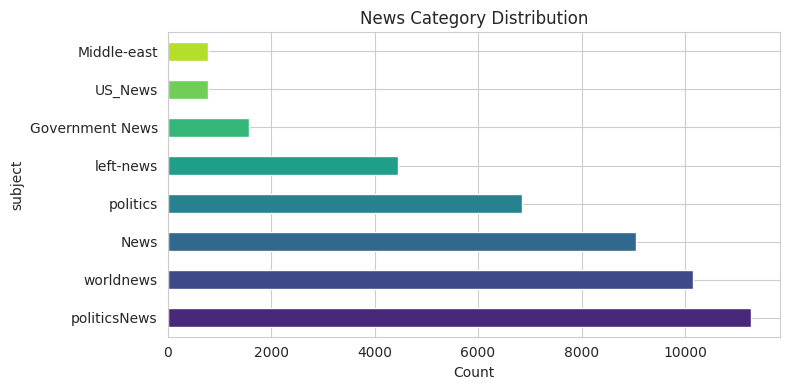

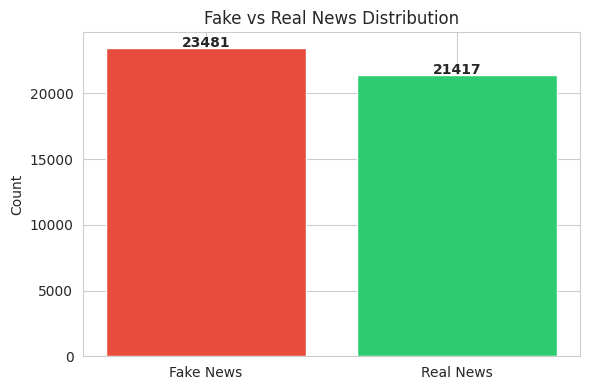

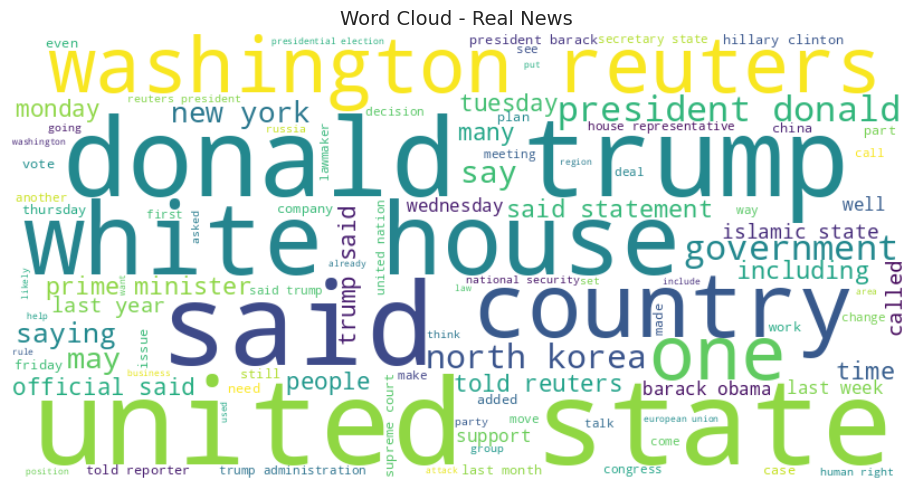

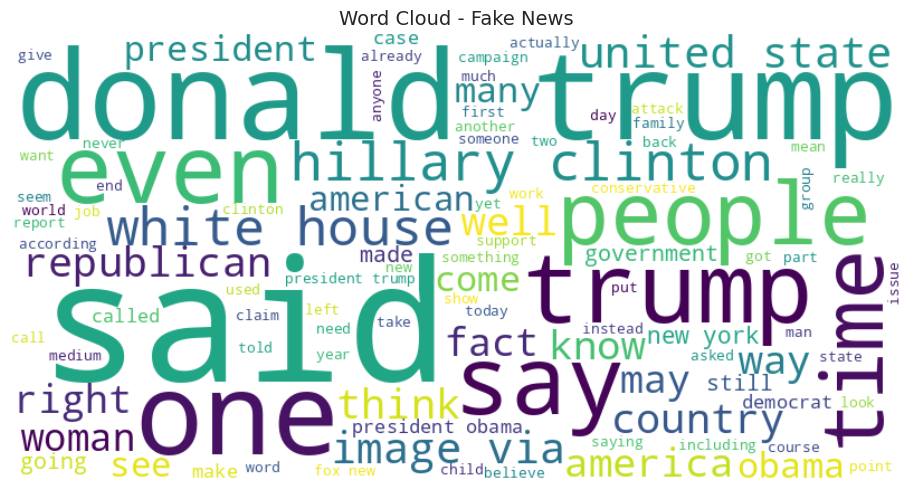

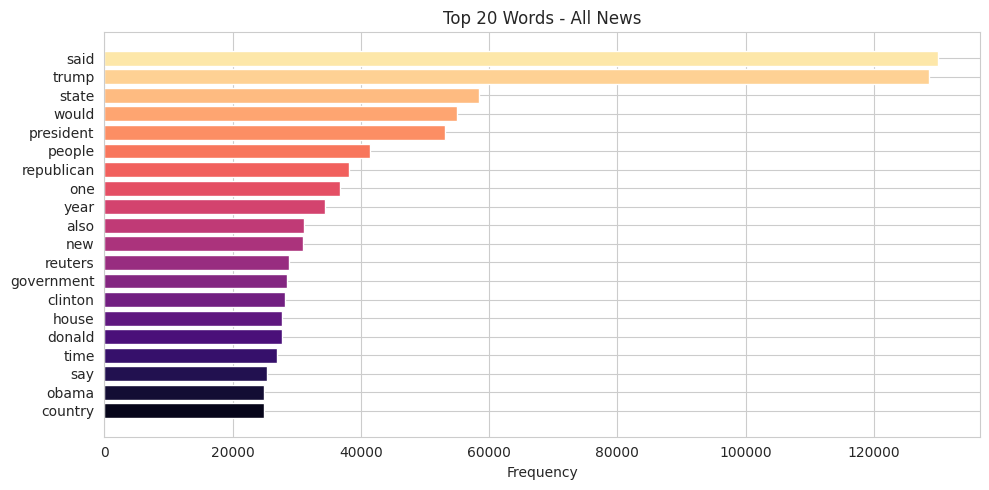

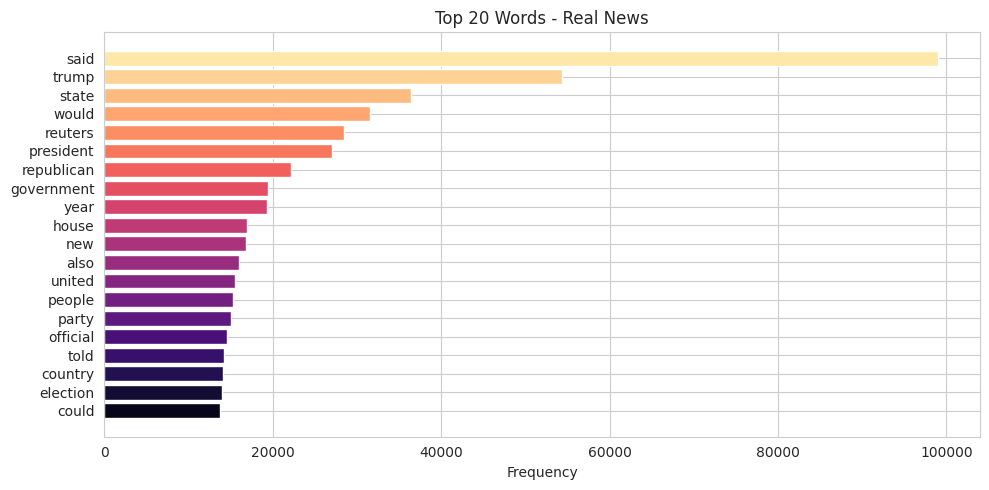

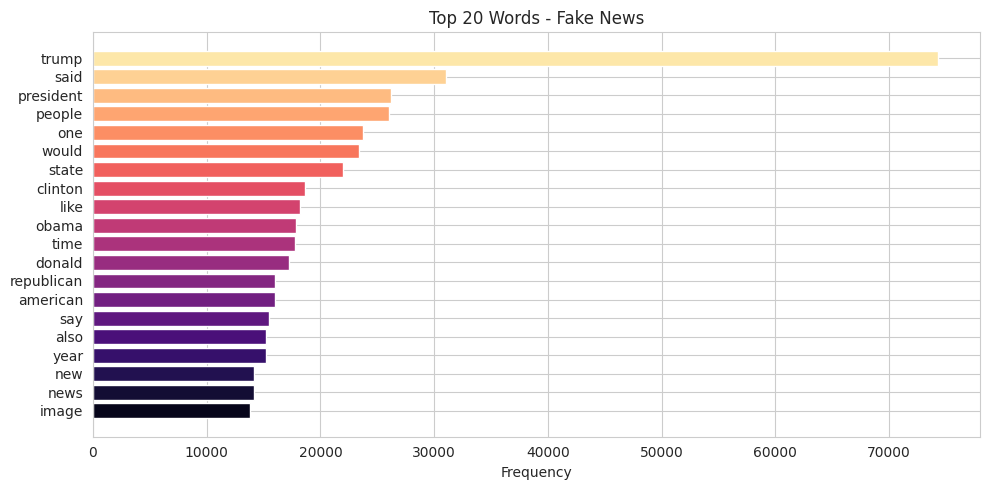

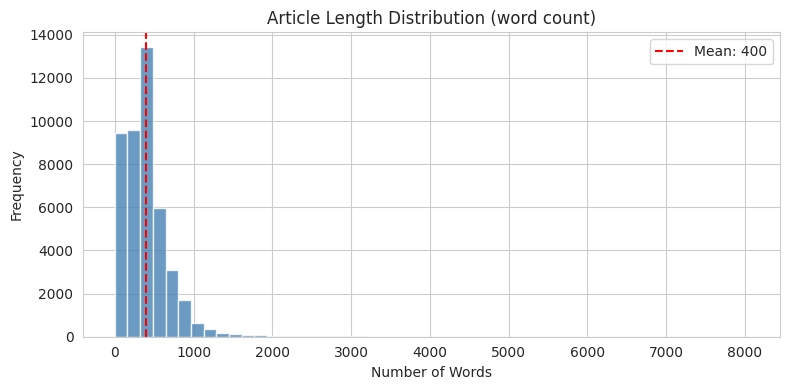

In [5]:
# ---------- EDA Functions ----------

# Function to plot the distribution of fake vs real news articles.
def plot_label_distribution(df, label_col='label'):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    counts = df[label_col].value_counts()
    labels = ['Fake News', 'Real News'] if 0 in counts.index else counts.index
    ax.bar(labels, counts.values, color=['#e74c3c', '#2ecc71'])
    ax.set_title('Fake vs Real News Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Function to plot the distribution of news categories (if 'subject' column exists).
def plot_category_distribution(df, cat_col='subject'):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    df[cat_col].value_counts().plot(kind='barh', ax=ax,
        color=sns.color_palette('viridis', len(df[cat_col].unique())))
    ax.set_title('News Category Distribution')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

# Function to plot word clouds for a list of texts.
def plot_wordcloud(texts, title='Word Cloud'):
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis')
    wc.generate(' '.join(texts))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Function to plot the most frequent words in a list of token lists.
def plot_most_frequent_words(tokens_list, n=20, title='Most Frequent Words'):
    all_tokens = [t for tokens in tokens_list for t in tokens]
    freq = Counter(all_tokens).most_common(n)
    words, counts = zip(*freq)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(words[::-1], counts[::-1], color=sns.color_palette('magma', n))
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()

# Function to plot the distribution of article lengths (in words).
def plot_article_length(df, text_col='cleaned'):
    lengths = df[text_col].apply(lambda x: len(x.split()))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title('Article Length Distribution (word count)')
    ax.set_xlabel('Number of Words')
    ax.set_ylabel('Frequency')
    ax.axvline(lengths.mean(), color='red', linestyle='--', label=f'Mean: {lengths.mean():.0f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Function to run all EDA steps in sequence.
def run_full_eda(df):
    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)
    print(f"\nDataset shape: {df.shape}")
    print(f"\nLabel distribution:\n{df['label'].value_counts()}")

    if 'subject' in df.columns:
        print(f"\nCategory distribution:\n{df['subject'].value_counts()}")
        plot_category_distribution(df)

    plot_label_distribution(df)

    real_texts = df[df['label'] == 1]['processed_text'].tolist()
    fake_texts = df[df['label'] == 0]['processed_text'].tolist()
    plot_wordcloud(real_texts, 'Word Cloud - Real News')
    plot_wordcloud(fake_texts, 'Word Cloud - Fake News')

    plot_most_frequent_words(df['tokens'].tolist(), title='Top 20 Words - All News')
    plot_most_frequent_words(df[df['label'] == 1]['tokens'].tolist(), title='Top 20 Words - Real News')
    plot_most_frequent_words(df[df['label'] == 0]['tokens'].tolist(), title='Top 20 Words - Fake News')

    plot_article_length(df)

# Run full EDA
run_full_eda(df)

---
## 3. Vector Embeddings

We have implemented below to perform vector embedding:
- **Word2Vec**: Neural embedding model trained on our corpus
- **TF-IDF**: Term frequency-inverse document frequency vectors

Word2Vec captures semantic relationships between words, while TF-IDF captures term importance.

In [6]:
# ---------- Vector Embedding Functions ----------

# Implementing a simple Word2Vec-like model using PPMI and SVD, along 
# with a custom class to mimic gensim's KeyedVectors interface.
class _WordVectors:
    """Mimics gensim KeyedVectors interface."""
    def __init__(self, word2idx, idx2word, vectors):
        self._word2idx = word2idx
        self._idx2word = idx2word
        self._vectors = vectors.astype(np.float32)
        norms = np.linalg.norm(self._vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1
        self._normalized = self._vectors / norms

    def __getitem__(self, word):
        return self._vectors[self._word2idx[word]]

    def __contains__(self, word):
        return word in self._word2idx

    def __len__(self):
        return len(self._word2idx)

    def most_similar(self, word, topn=10):
        if word not in self._word2idx:
            return []
        idx = self._word2idx[word]
        vec = self._normalized[idx]
        sims = self._normalized @ vec
        sims[idx] = -1
        top_idx = np.argsort(sims)[::-1][:topn]
        return [(self._idx2word[i], float(sims[i])) for i in top_idx]

    def similarity(self, w1, w2):
        if w1 not in self._word2idx or w2 not in self._word2idx:
            return 0.0
        v1 = self._normalized[self._word2idx[w1]]
        v2 = self._normalized[self._word2idx[w2]]
        return float(np.dot(v1, v2))

# Simple wrapper class to mimic gensim's Word2Vec model with .wv and .vector_size attributes.
class SimpleWord2Vec:
    """Trained Word2Vec model exposing .wv and .vector_size like gensim."""
    def __init__(self):
        self.wv = None
        self.vector_size = 0

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({'vectors': self.wv._vectors,
                         'word2idx': self.wv._word2idx,
                         'idx2word': self.wv._idx2word,
                         'vector_size': self.vector_size}, f)
        print(f"Word2Vec model saved to {path}")

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        m = SimpleWord2Vec()
        m.vector_size = data['vector_size']
        m.wv = _WordVectors(data['word2idx'], data['idx2word'], data['vectors'])
        return m

# Function to train word embeddings using PPMI + TruncatedSVD.
def train_word2vec(token_lists, vector_size=100, window=5, min_count=3, epochs=10):
    """Train word embeddings using PPMI + TruncatedSVD."""
    print("Building co-occurrence matrix (PPMI + SVD Word2Vec)...")
    texts = [' '.join(tokens) for tokens in token_lists]
    cv = CountVectorizer(min_df=min_count, max_features=20000, token_pattern=r'\S+')
    X = cv.fit_transform(texts).astype(np.float32)

    vocab = cv.get_feature_names_out()
    word2idx = {w: int(i) for i, w in enumerate(vocab)}
    idx2word = {int(i): w for i, w in enumerate(vocab)}
    vocab_size = len(vocab)

    cooc = (X.T @ X).tocsr()
    cooc = cooc - sp.diags(np.array(cooc.diagonal()).ravel())
    cooc.eliminate_zeros()

    total = float(cooc.sum())
    w_freq = np.array(cooc.sum(axis=1), dtype=np.float64).ravel()
    c_freq = np.array(cooc.sum(axis=0), dtype=np.float64).ravel()

    rows, cols = cooc.nonzero()
    vals = np.array(cooc[rows, cols], dtype=np.float64).ravel()
    pmi = np.log(vals * total / (w_freq[rows] * c_freq[cols] + 1e-10) + 1e-10)
    ppmi_vals = np.maximum(pmi, 0)
    ppmi = sp.csr_matrix((ppmi_vals, (rows, cols)), shape=(vocab_size, vocab_size))

    n_comp = min(vector_size, vocab_size - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42, n_iter=5)
    embeddings = svd.fit_transform(ppmi).astype(np.float32)

    w2v = SimpleWord2Vec()
    w2v.vector_size = n_comp
    w2v.wv = _WordVectors(word2idx, idx2word, embeddings)
    print(f"Word2Vec (PPMI+SVD) trained: vocab={vocab_size}, dim={n_comp}, "
          f"explained_var={svd.explained_variance_ratio_.sum():.3f}")
    return w2v

# Function to get a document vector by averaging word vectors for the tokens in the document.
def get_document_vector_w2v(tokens, model):
    """Average word vectors to get a single document vector."""
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.vector_size, dtype=np.float32)

# Function to build a TF-IDF matrix from a list of texts.
def build_tfidf(texts, max_features=10000):
    """Build TF-IDF matrix."""
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(texts)
    print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
    return vectorizer, tfidf_matrix

# Function to show the most similar words to a given word using the trained Word2Vec model.
def show_similar_words(model, word, topn=10):
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=topn)
        print(f"\nWords most similar to '{word}':")
        for w, score in similar:
            print(f"  {w:20s} {score:.4f}")
        return similar
    else:
        print(f"'{word}' not in vocabulary.")
        return []

# Function to show the semantic similarity between pairs of words using the trained Word2Vec model.
def show_semantic_similarity(model, pairs):
    print("\nSemantic Similarity (Word2Vec):")
    print("-" * 40)
    for w1, w2 in pairs:
        if w1 in model.wv and w2 in model.wv:
            sim = model.wv.similarity(w1, w2)
            print(f"  {w1:15s} <-> {w2:15s} : {sim:.4f}")
        else:
            print(f"  {w1:15s} <-> {w2:15s} : (not in vocab)")


# Train Word2Vec
w2v_model = train_word2vec(df['tokens'].tolist(), vector_size=100, window=5, min_count=3, epochs=15)

# Build TF-IDF
tfidf_vectorizer, tfidf_matrix = build_tfidf(df['processed_text'].tolist(), max_features=10000)

Building co-occurrence matrix (PPMI + SVD Word2Vec)...
Word2Vec (PPMI+SVD) trained: vocab=20000, dim=100, explained_var=0.256
TF-IDF matrix shape: (44898, 10000)


In [7]:
# Semantic similarity examples
for word in ['trump', 'election', 'health', 'technology', 'sports', 'economy']:
    show_similar_words(w2v_model, word, topn=5)

# Word pair similarities
pairs = [
    ('president', 'government'), ('fake', 'real'),
    ('democrat', 'republican'), ('health', 'medical'),
    ('economy', 'market'), ('war', 'peace')
]
show_semantic_similarity(w2v_model, pairs)


Words most similar to 'trump':
  donald               0.9382
  kellyanne            0.9202
  spicer               0.8844
  conway               0.8825
  lashed               0.8703

Words most similar to 'election':
  electoral            0.8681
  poll                 0.8454
  polling              0.8161
  party                0.8147
  turnout              0.8078

Words most similar to 'health':
  newborn              0.8379
  medicaid             0.8314
  patient              0.8225
  care                 0.8064
  affordable           0.8037

Words most similar to 'technology':
  startup              0.8699
  electric             0.8472
  motor                0.8356
  automobile           0.8277
  tesla                0.8258
'sports' not in vocabulary.

Words most similar to 'economy':
  economist            0.8625
  sector               0.8562
  index                0.8533
  market               0.8524
  economics            0.8507

Semantic Similarity (Word2Vec):
------------------

---
## 4. Neural Language Model (LSTM)

We built an **LSTM-based Neural Language Model** that:
- Learns language patterns from news articles
- Predicts the next word given a sequence of words
- Demonstrates contextual understanding of news language

**Architecture:** Embedding --> 2-layer LSTM --> Fully Connected --> Softmax

In [8]:
# ---------- Neural Language Model Functions ----------

# Implementing a simple LSTM-based neural language model using PyTorch, 
# along with a custom Dataset class for training.
class TextDataset(Dataset):
    """Dataset for language modeling with sequence windows."""
    def __init__(self, token_sequences, word2idx, seq_length=10):
        self.seq_length = seq_length
        self.word2idx = word2idx
        self.data = []
        for tokens in token_sequences:
            indices = [word2idx.get(t, word2idx.get('<UNK>', 0)) for t in tokens]
            for i in range(len(indices) - seq_length):
                self.data.append((indices[i:i + seq_length], indices[i + seq_length]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

# LSTM based Neural Language Model 
class LSTMLanguageModel(nn.Module):
    """LSTM-based Neural Language Model."""
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embeds = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(embeds)
        out = self.fc(self.dropout(lstm_out[:, -1, :]))
        return out

# Function to build a vocabulary from token lists, filtering by minimum frequency.
def build_vocab(token_lists, min_freq=3):
    counter = Counter(t for tokens in token_lists for t in tokens)
    vocab = ['<PAD>', '<UNK>'] + [w for w, c in counter.most_common() if c >= min_freq]
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    print(f"Vocabulary size: {len(vocab)}")
    return word2idx, idx2word

# Function to train the LSTM language model.
def train_language_model(model, dataloader, epochs=10, lr=0.001, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_loss = total_loss / max(n_batches, 1)
        losses.append(avg_loss)
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses

# Function to predict the next words given a seed text using the trained language model.
def predict_next_words(model, seed_text, word2idx, idx2word, seq_length=10, n_words=5, device='cpu'):
    model.eval()
    tokens = seed_text.lower().split()
    indices = [word2idx.get(t, word2idx.get('<UNK>', 0)) for t in tokens]
    if len(indices) < seq_length:
        indices = [word2idx.get('<PAD>', 0)] * (seq_length - len(indices)) + indices
    else:
        indices = indices[-seq_length:]
    predicted = list(tokens)
    with torch.no_grad():
        for _ in range(n_words):
            x = torch.tensor([indices[-seq_length:]], dtype=torch.long).to(device)
            output = model(x)
            probs = torch.softmax(output, dim=-1)
            top_idx = torch.multinomial(probs[0], 1).item()
            word = idx2word.get(top_idx, '<UNK>')
            predicted.append(word)
            indices.append(top_idx)
    return ' '.join(predicted)

# Function to plot the training loss curve over epochs.
def plot_loss_curve(losses):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(losses) + 1), losses, marker='o', color='steelblue')
    ax.set_title('Neural Language Model - Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Training configuration
N_ARTICLES  = 5000
BATCH_SIZE  = 256
LM_EPOCHS   = 15

sample_tokens = df['tokens'].tolist()[:N_ARTICLES]

# Build vocabulary
word2idx, idx2word = build_vocab(sample_tokens, min_freq=3)

# Create the dataset
SEQ_LENGTH = 10
dataset = TextDataset(sample_tokens, word2idx, seq_length=SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Device: {DEVICE} | Articles: {N_ARTICLES} | Batch: {BATCH_SIZE} | Epochs: {LM_EPOCHS}")
print(f"Training sequences: {len(dataset)}")

Vocabulary size: 20497
Device: cpu | Articles: 5000 | Batch: 256 | Epochs: 15
Training sequences: 1074825


Model parameters: 4,187,345

Training Neural Language Model...
  Epoch 1/15, Loss: 7.9957
  Epoch 2/15, Loss: 7.6452
  Epoch 4/15, Loss: 7.3225
  Epoch 6/15, Loss: 7.1513
  Epoch 8/15, Loss: 7.0400
  Epoch 10/15, Loss: 6.9539
  Epoch 12/15, Loss: 6.8913
  Epoch 14/15, Loss: 6.8413


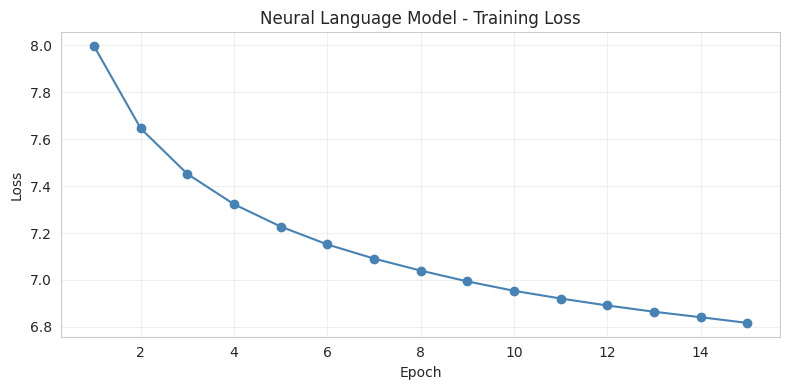

In [9]:
# Build and train model
vocab_size = len(word2idx)
lm_model = LSTMLanguageModel(vocab_size, embed_dim=64, hidden_dim=128, num_layers=2)
print(f"Model parameters: {sum(p.numel() for p in lm_model.parameters()):,}")

print("\nTraining Neural Language Model...")
losses = train_language_model(lm_model, dataloader, epochs=LM_EPOCHS, lr=0.002, device=DEVICE)
plot_loss_curve(losses)

In [10]:
# Next word prediction examples
seed_texts = [
    "the president said that the",
    "breaking news from the white",
    "the government announced new policy",
    "according to official report the",
]

print("Next Word Predictions:")
print("=" * 60)
for seed in seed_texts:
    result = predict_next_words(lm_model, seed, word2idx, idx2word,
                                seq_length=SEQ_LENGTH, n_words=5, device=DEVICE)
    print(f"  Input: '{seed}'")
    print(f"  Output: '{result}'\n")

Next Word Predictions:
  Input: 'the president said that the'
  Output: 'the president said that the charge back kronor long noted'

  Input: 'breaking news from the white'
  Output: 'breaking news from the white house spokesman sean spicer looked'

  Input: 'the government announced new policy'
  Output: 'the government announced new policy united state called peacekeeping <UNK>'

  Input: 'according to official report the'
  Output: 'according to official report the brought trump unlike didnt forget'



---
## 5. POS Tagging

Part-of-Speech tagging identifies the grammatical role of each word:
- **Nouns (NN)**: People, places, things
- **Verbs (VB)**: Actions
- **Adjectives (JJ)**: Descriptors
- **Named Entities**: People, organizations, locations

We use both **NLTK** and **SpaCy** for comparison.

In [11]:
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Downloading SpaCy model...")
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print("SpaCy model loaded.")

SpaCy model loaded.


In [12]:
# ---------- POS Tagging Functions ----------

# Function to perform POS tagging on a given text using NLTK.
def pos_tag_text(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    return tagged

# Function to extract nouns, verbs, and adjectives from POS-tagged text.
def extract_pos_categories(tagged):
    nouns = [w for w, t in tagged if t.startswith('NN')]
    verbs = [w for w, t in tagged if t.startswith('VB')]
    adjectives = [w for w, t in tagged if t.startswith('JJ')]
    return {'nouns': nouns, 'verbs': verbs, 'adjectives': adjectives}

# Function to extract named entities from text using NLTK's ne_chunk.
def extract_named_entities(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    tree = ne_chunk(tagged)
    entities = []
    for subtree in tree:
        if hasattr(subtree, 'label'):
            entity = ' '.join(w for w, t in subtree.leaves())
            entities.append((entity, subtree.label()))
    return entities

# Function to perform POS tagging and named entity recognition using SpaCy.
def spacy_analysis(text, nlp):
    doc = nlp(text[:100000])
    pos_tags = [(token.text, token.pos_, token.dep_) for token in doc]
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return pos_tags, entities

# Function to display a summary of POS tagging analysis, including sample tags, top categories, and named entities.
def display_pos_summary(text, nlp=None):
    print("\n" + "=" * 60)
    print("POS TAGGING ANALYSIS")
    print("=" * 60)

    tagged = pos_tag_text(text)
    categories = extract_pos_categories(tagged)

    print(f"\nSample POS Tags (first 20): {tagged[:20]}")
    print(f"\nTop Nouns: {Counter(categories['nouns']).most_common(10)}")
    print(f"Top Verbs: {Counter(categories['verbs']).most_common(10)}")
    print(f"Top Adjectives: {Counter(categories['adjectives']).most_common(10)}")

    entities = extract_named_entities(text)
    print(f"\nNamed Entities (first 15): {entities[:15]}")

    if nlp is not None:
        pos_tags, sp_entities = spacy_analysis(text, nlp)
        print(f"\nSpaCy Entities (first 15): {sp_entities[:15]}")

    return tagged, categories, entities


# Analyze sample articles
for i, idx in enumerate([0, 1, 2]):
    label = 'REAL' if df['label'].iloc[idx] == 1 else 'FAKE'
    print(f"\n{'#' * 60}")
    print(f"Article {i+1} ({label})")
    print(f"{'#' * 60}")
    sample_text = df['text'].iloc[idx][:1000]
    display_pos_summary(sample_text, nlp=nlp)


############################################################
Article 1 (FAKE)
############################################################

POS TAGGING ANALYSIS

Sample POS Tags (first 20): [('Donald', 'NNP'), ('Trump', 'NNP'), ('s', 'VBD'), ('White', 'NNP'), ('House', 'NNP'), ('is', 'VBZ'), ('in', 'IN'), ('chaos', 'NN'), (',', ','), ('and', 'CC'), ('they', 'PRP'), ('are', 'VBP'), ('trying', 'VBG'), ('to', 'TO'), ('cover', 'VB'), ('it', 'PRP'), ('up', 'RP'), ('.', '.'), ('Their', 'PRP$'), ('Russia', 'NN')]

Top Nouns: [('Trump', 6), ('Donald', 3), ('White', 2), ('problems', 2), ('fact', 2), ('House', 1), ('chaos', 1), ('Russia', 1), ('hour', 1), ('news', 1)]
Top Verbs: [('is', 4), ('are', 4), ('s', 3), ('seems', 3), ('trying', 1), ('cover', 1), ('mounting', 1), ('refuse', 1), ('acknowledge', 1), ('surrounding', 1)]
Top Adjectives: [('shady', 2), ('fake', 1), ('public', 1), ('former', 1), ('infamous', 1), ('Democratic', 1), ('due', 1), ('few', 1), ('Special', 1)]

Named Entities (first

---
## 6. Hidden Markov Model (HMM)

We use HMM for:
1. **POS Sequence Modeling**: Learning transition probabilities between POS tags
2. **Fake News Feature Extraction**: Modeling sequence patterns that differ between fake and real news

HMM captures:
- **Transition probabilities**: P(tag_t | tag_{t-1})
- **Emission probabilities**: P(word | tag)
- **Starting probabilities**: P(first tag in sentence)

In [13]:
# ---------- HMM Functions ----------

# Function to build a simple HMM POS tagger by estimating transition 
# probabilities and starting probabilities from tagged sentences.
def build_hmm_pos_tagger(tagged_sentences, n_states=12):
    all_tags = [t for tagged in tagged_sentences for _, t in tagged]
    tag_encoder = LabelEncoder()
    tag_encoder.fit(list(set(all_tags)))
    n_tags = len(tag_encoder.classes_)

    transition = np.zeros((n_tags, n_tags))
    for tagged in tagged_sentences:
        tag_ids = tag_encoder.transform([t for _, t in tagged])
        for i in range(len(tag_ids) - 1):
            transition[tag_ids[i], tag_ids[i + 1]] += 1

    row_sums = transition.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    transition /= row_sums

    start_probs = np.zeros(n_tags)
    for tagged in tagged_sentences:
        if tagged:
            start_probs[tag_encoder.transform([tagged[0][1]])[0]] += 1
    total = start_probs.sum()
    start_probs /= max(total, 1)

    print(f"HMM POS Tagger built: {n_tags} states (POS tags)")
    print(f"Transition matrix shape: {transition.shape}")
    return transition, start_probs, tag_encoder

# Function to display the results of the HMM analysis, including the number 
# of states, sample states, starting probabilities, and sample transition probabilities.
def display_hmm_results(transition, start_probs, tag_encoder):
    print("\n" + "=" * 60)
    print("HIDDEN MARKOV MODEL ANALYSIS")
    print("=" * 60)
    classes = tag_encoder.classes_
    print(f"\nNumber of hidden states (POS tags): {len(classes)}")
    print(f"States: {list(classes[:15])}...")

    print("\nStarting probabilities (top 5):")
    for idx in np.argsort(start_probs)[::-1][:5]:
        print(f"  {classes[idx]:5s}: {start_probs[idx]:.4f}")

    print("\nSample transition probabilities:")
    for i in range(min(5, len(classes))):
        for j in np.argsort(transition[i])[::-1][:3]:
            if transition[i, j] > 0.01:
                print(f"  {classes[i]:5s} -> {classes[j]:5s}: {transition[i, j]:.4f}")

# Function to extract HMM-based features from the text data and classify fake vs real news 
# using a simple logistic regression on those features.
def hmm_fake_news_features(df, text_col='cleaned'):
    vectorizer = CountVectorizer(max_features=50, stop_words='english')
    X = vectorizer.fit_transform(df[text_col]).toarray().astype(float)

    svd = TruncatedSVD(n_components=5, random_state=42)
    X_reduced = svd.fit_transform(X)

    n_states = 4
    X_min = X_reduced.min(axis=0)
    X_max = X_reduced.max(axis=0)
    X_norm = (X_reduced - X_min) / (X_max - X_min + 1e-10)
    X_disc = (X_norm * (n_states - 1)).astype(int).clip(0, n_states - 1)

    labels = df['label'].values[:len(X_disc)]
    results = {}

    for label, name in [(0, 'Fake'), (1, 'Real')]:
        data = X_disc[labels == label][:500]
        trans = np.zeros((n_states, n_states))
        for row in data:
            for i in range(len(row) - 1):
                trans[row[i], row[i + 1]] += 1
        row_sums = trans.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        trans_norm = trans / row_sums
        eps = 1e-10
        entropy = float(-np.sum(trans_norm * np.log(trans_norm + eps)))
        mean_state = float(data.mean())
        results[name] = {
            'transition_matrix': trans_norm,
            'entropy': entropy,
            'mean_state': mean_state,
        }
        print(f"  HMM for {name} news: n_states={n_states}, "
              f"entropy={entropy:.4f}, mean_state={mean_state:.4f}")
    return results

# Function to classify fake vs real news using HMM-based features and evaluate the results.
def hmm_classify_fake_news(df, text_col='cleaned', label_col='label', test_size=0.2):
    print("Extracting per-document HMM sequence features...")
    vectorizer = CountVectorizer(max_features=50, stop_words='english')
    X_raw = vectorizer.fit_transform(df[text_col]).toarray().astype(float)

    svd = TruncatedSVD(n_components=5, random_state=42)
    X_reduced = svd.fit_transform(X_raw)

    n_states = 4
    X_min  = X_reduced.min(axis=0)
    X_max  = X_reduced.max(axis=0)
    X_norm = (X_reduced - X_min) / (X_max - X_min + 1e-10)
    X_disc = (X_norm * (n_states - 1)).astype(int).clip(0, n_states - 1)

    eps = 1e-10
    features = []
    for row in X_disc:
        trans = np.zeros((n_states, n_states))
        for i in range(len(row) - 1):
            trans[row[i], row[i + 1]] += 1
        row_sums = trans.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        trans_norm = trans / row_sums
        entropy    = float(-np.sum(trans_norm * np.log(trans_norm + eps)))
        mean_state = float(row.mean())
        features.append([entropy, mean_state])

    features = np.array(features)
    labels   = df[label_col].values[:len(features)]

    X_tr, X_te, y_tr, y_te = train_test_split(
        features, labels, test_size=test_size, random_state=42, stratify=labels)

    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted')

    print("\n" + "=" * 60)
    print("HMM-BASED FAKE NEWS DETECTION RESULTS")
    print("=" * 60)
    print(f"Features used : transition entropy, mean discretised state")
    print(f"Classifier    : Logistic Regression on HMM features")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 (weighted) : {f1:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Fake', 'Real']))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], ax=ax)
    ax.set_title(f'HMM Fake News Detection\nAccuracy: {acc:.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return acc, f1, y_te, y_pred, clf, features


# Build POS-tagged sentences for HMM
print("POS tagging sample sentences for HMM...")
sample_texts = df['text'].iloc[:500].tolist()
tagged_sentences = []
for text in sample_texts:
    words = text.split()[:50]
    tagged = pos_tag_text(' '.join(words))
    if len(tagged) > 3:
        tagged_sentences.append(tagged)

print(f"Tagged {len(tagged_sentences)} sentences")

# Build HMM
transition, start_probs, tag_encoder = build_hmm_pos_tagger(tagged_sentences)
display_hmm_results(transition, start_probs, tag_encoder)

POS tagging sample sentences for HMM...
Tagged 490 sentences
HMM POS Tagger built: 42 states (POS tags)
Transition matrix shape: (42, 42)

HIDDEN MARKOV MODEL ANALYSIS

Number of hidden states (POS tags): 42
States: [np.str_('#'), np.str_('$'), np.str_('('), np.str_(')'), np.str_(','), np.str_('.'), np.str_(':'), np.str_('CC'), np.str_('CD'), np.str_('DT'), np.str_('EX'), np.str_('FW'), np.str_('IN'), np.str_('JJ'), np.str_('JJR')]...

Starting probabilities (top 5):
  NNP  : 0.5816
  DT   : 0.1000
  IN   : 0.0592
  NN   : 0.0449
  JJ   : 0.0449

Sample transition probabilities:
  #     -> NNP  : 0.8571
  #     -> NNS  : 0.0714
  #     -> CD   : 0.0714
  $     -> CD   : 0.9231
  $     -> MD   : 0.0385
  $     -> JJ   : 0.0385
  (     -> NNP  : 0.7741
  (     -> NNPS : 0.1444
  (     -> CD   : 0.0148
  )     -> :    : 0.7865
  )     -> NNP  : 0.0599
  )     -> IN   : 0.0487
  ,     -> NNP  : 0.1794
  ,     -> DT   : 0.1368
  ,     -> VBG  : 0.0818


In [14]:
# HMM for fake vs real news sequence analysis
print("\nHMM Fake vs Real News Analysis:")
print("-" * 40)
hmm_results = hmm_fake_news_features(df.iloc[:2000], text_col='cleaned')


HMM Fake vs Real News Analysis:
----------------------------------------
  HMM for Fake news: n_states=4, entropy=1.3203, mean_state=0.2656
  HMM for Real news: n_states=4, entropy=0.7938, mean_state=0.1976


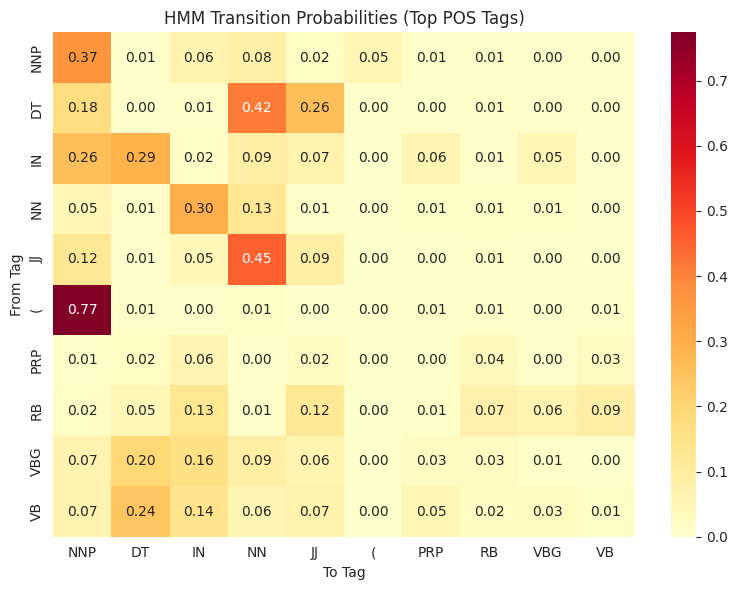

In [15]:
# Visualize transition matrix
top_n = 10
top_tags = np.argsort(start_probs)[::-1][:top_n]
tag_names = tag_encoder.classes_[top_tags]
sub_trans = transition[np.ix_(top_tags, top_tags)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sub_trans, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=tag_names, yticklabels=tag_names, ax=ax)
ax.set_title('HMM Transition Probabilities (Top POS Tags)')
ax.set_xlabel('To Tag')
ax.set_ylabel('From Tag')
plt.tight_layout()
plt.show()

### 6b. HMM-Based Fake News Detection

Using per-document HMM sequence features (transition entropy + mean discrete state) as input to a classifier, we evaluate how well HMM probabilistic patterns alone can distinguish fake from real news.

Extracting per-document HMM sequence features...

HMM-BASED FAKE NEWS DETECTION RESULTS
Features used : transition entropy, mean discretised state
Classifier    : Logistic Regression on HMM features
Accuracy      : 0.7008
F1 (weighted) : 0.6843

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.65      0.91      0.76      4696
        Real       0.83      0.47      0.60      4284

    accuracy                           0.70      8980
   macro avg       0.74      0.69      0.68      8980
weighted avg       0.74      0.70      0.68      8980



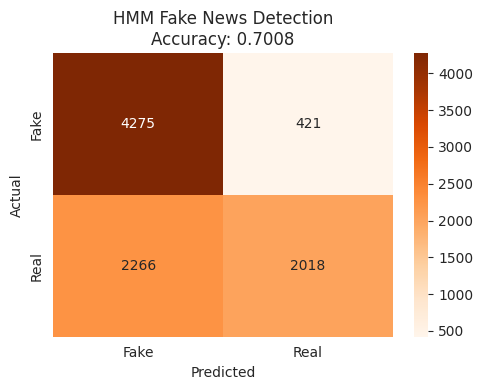

In [16]:
# Run HMM-based fake news classification with evaluation metrics
hmm_acc, hmm_f1, hmm_y_test, hmm_y_pred, hmm_clf, hmm_features = hmm_classify_fake_news(
    df, text_col='cleaned', label_col='label'
)

---
## 7. Syntactic Parsing

We perform **dependency parsing** using SpaCy to:
- Analyze sentence structure
- Extract Subject-Verb-Object (SVO) triples
- Identify noun chunks
- Understand entity relationships

In [17]:
# -- Parsing Functions --------------------------------------------------------

def dependency_parse(text, nlp):
    doc = nlp(text[:5000])
    triples = []
    for token in doc:
        if token.dep_ in ('nsubj', 'nsubjpass'):
            subject = token.text
            verb = token.head.text
            obj = ''
            for child in token.head.children:
                if child.dep_ in ('dobj', 'attr', 'pobj'):
                    obj = child.text
                    break
            triples.append({'subject': subject, 'verb': verb, 'object': obj})
    return triples, doc


def display_parse_results(text, nlp):
    print("\n" + "=" * 60)
    print("SYNTACTIC PARSING ANALYSIS")
    print("=" * 60)

    doc = nlp(text[:3000])

    print("\nDependency Parse (first 15 tokens):")
    print(f"{'Token':15s} {'POS':8s} {'Dep':12s} {'Head':15s}")
    print("-" * 55)
    for token in list(doc)[:15]:
        print(f"{token.text:15s} {token.pos_:8s} {token.dep_:12s} {token.head.text:15s}")

    triples, _ = dependency_parse(text, nlp)
    print(f"\nExtracted Subject-Verb-Object Triples (first 10):")
    for i, t in enumerate(triples[:10]):
        print(f"  {i + 1}. {t['subject']} -- {t['verb']} --> {t['object']}")

    chunks = [(chunk.text, chunk.root.dep_) for chunk in doc.noun_chunks]
    print(f"\nNoun Chunks (first 10): {chunks[:10]}")
    return triples


# Parse sample articles
for i in range(3):
    label = 'REAL' if df['label'].iloc[i] == 1 else 'FAKE'
    print(f"\n{'#' * 60}")
    print(f"Parsing Article {i+1} ({label})")
    print(f"{'#' * 60}")
    display_parse_results(df['text'].iloc[i], nlp)


############################################################
Parsing Article 1 (FAKE)
############################################################

SYNTACTIC PARSING ANALYSIS

Dependency Parse (first 15 tokens):
Token           POS      Dep          Head           
-------------------------------------------------------
Donald          PROPN    compound     Trump          
Trump           PROPN    poss         House          
s               PART     case         Trump          
White           PROPN    compound     House          
House           PROPN    nsubj        is             
is              AUX      ROOT         is             
in              ADP      prep         is             
chaos           NOUN     pobj         in             
,               PUNCT    punct        is             
and             CCONJ    cc           is             
they            PRON     nsubj        trying         
are             AUX      aux          trying         
trying          VERB     conj

---
## 8. News Classification

We train and compare three classifiers:
- **Logistic Regression**: Linear model, good baseline
- **Naive Bayes**: Probabilistic, fast, good for text
- **Random Forest**: Ensemble method, captures non-linear patterns

Features: TF-IDF vectors

In [18]:
# -- Classifier Functions -----------------------------------------------------

# Function to train and evaluate multiple classifiers (Logistic Regression, 
# Naive Bayes, Random Forest) on the given feature matrix and labels, and 
# return the results along with training/testing splits.
def train_evaluate_classifiers(X, y, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y)

    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Naive Bayes': MultinomialNB(),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    }

    results = {}
    for name, clf in classifiers.items():
        print(f"\nTraining {name}...")
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        results[name] = {
            'model': clf, 'accuracy': acc, 'f1': f1,
            'precision': prec, 'recall': rec,
            'y_pred': y_pred, 'y_test': y_test,
        }
        print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    return results, X_train, X_test, y_train, y_test

# Function to plot confusion matrices for the given classification results, showing the accuracy in the title.
def plot_confusion_matrices(results, labels=None):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(res['y_test'], res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=labels or ['Fake', 'Real'],
                    yticklabels=labels or ['Fake', 'Real'])
        ax.set_title(f'{name}\nAcc: {res["accuracy"]:.4f}')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Function to plot a comparison of the performance metrics (accuracy, F1, precision, recall) for the different classifiers.
def plot_comparison(results):
    metrics = ['accuracy', 'f1', 'precision', 'recall']
    names = list(results.keys())
    x = np.arange(len(names))
    width = 0.2
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, metric in enumerate(metrics):
        values = [results[n][metric] for n in names]
        ax.bar(x + i * width, values, width, label=metric.capitalize())
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('Classifier Performance Comparison')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Function to print detailed classification reports for each classifier in the results.
def print_classification_reports(results, labels=None):
    for name, res in results.items():
        print(f"\n{'=' * 60}")
        print(f"Classification Report: {name}")
        print('=' * 60)
        print(classification_report(res['y_test'], res['y_pred'],
                                    target_names=labels or ['Fake', 'Real']))


# Fake News Detection using TF-IDF features
print("=" * 60)
print("FAKE NEWS CLASSIFICATION")
print("=" * 60)

X = tfidf_matrix
y = df['label'].values

results, X_train, X_test, y_train, y_test = train_evaluate_classifiers(X, y)

FAKE NEWS CLASSIFICATION

Training Logistic Regression...
  Accuracy: 0.9888 | F1: 0.9888 | Precision: 0.9888 | Recall: 0.9888

Training Naive Bayes...
  Accuracy: 0.9492 | F1: 0.9492 | Precision: 0.9493 | Recall: 0.9492

Training Random Forest...
  Accuracy: 0.9969 | F1: 0.9969 | Precision: 0.9969 | Recall: 0.9969


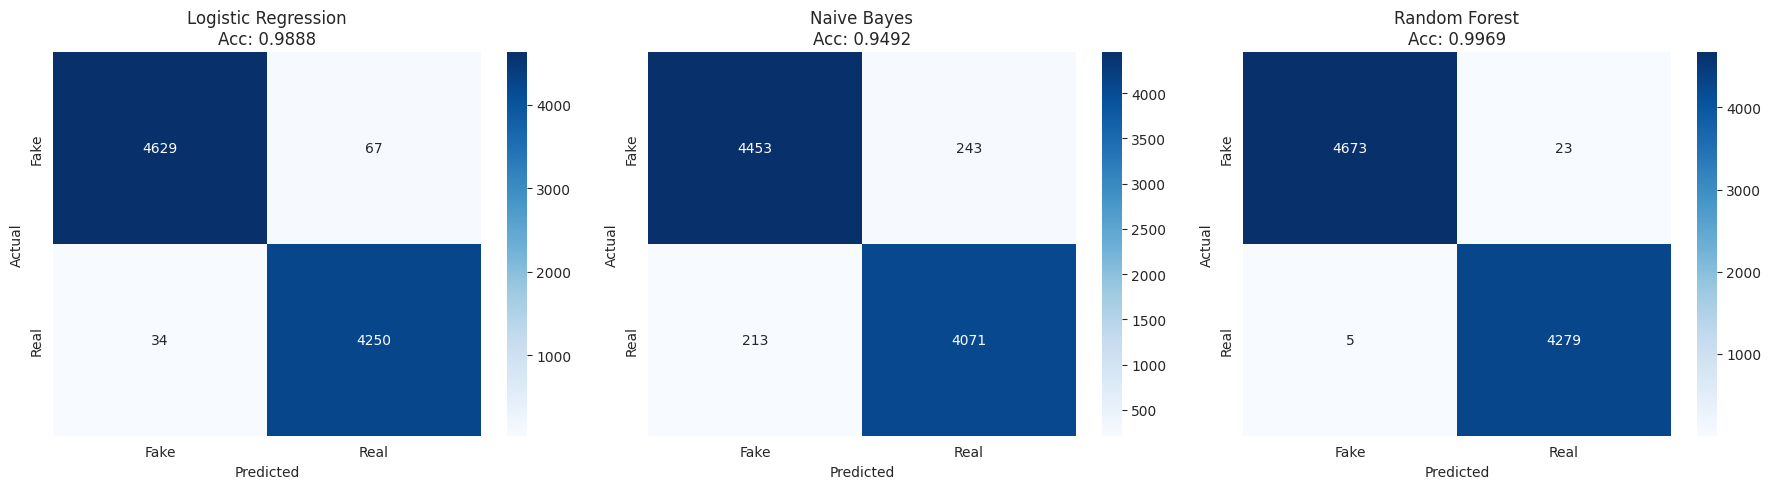

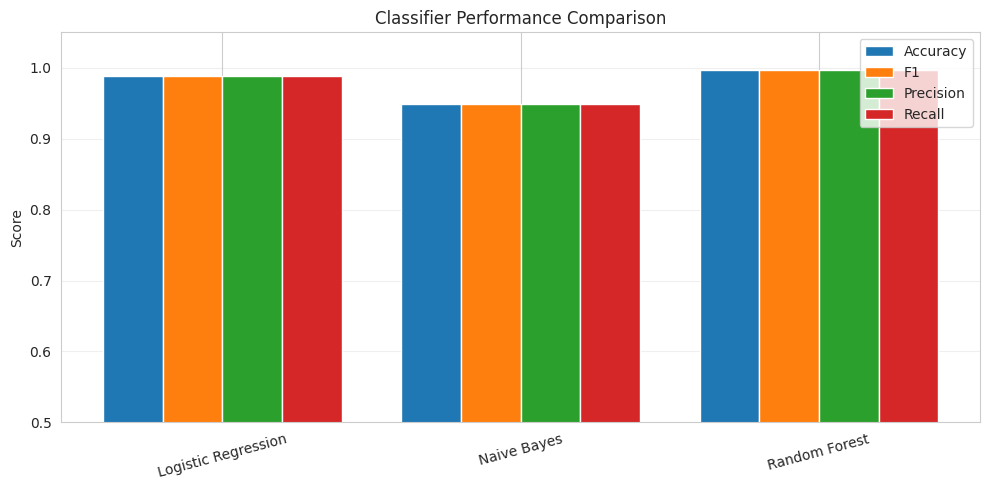


Classification Report: Logistic Regression
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Classification Report: Naive Bayes
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95      4696
        Real       0.94      0.95      0.95      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980


Classification Report: Random Forest
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro a

In [19]:
# Confusion matrices
plot_confusion_matrices(results)

# Performance comparison
plot_comparison(results)

# Detailed reports
print_classification_reports(results)

---
## 8b. Multi-Class News Category Classification

We classify each article into one of six topic categories:
**Politics, Technology, Sports, Entertainment, Business, Health**

Since the Fake/Real dataset does not carry explicit topic labels, we derive
ground-truth labels via **keyword matching** — each article is assigned the
category whose keyword list scores the most hits in the article text.
A TF-IDF + multi-class classifier is then trained and evaluated on these labels.

MULTI-CLASS NEWS CATEGORY CLASSIFICATION
Category distribution:
category
Politics         35310
Business          3127
Technology        2580
Sports            1820
Health            1175
Entertainment      886


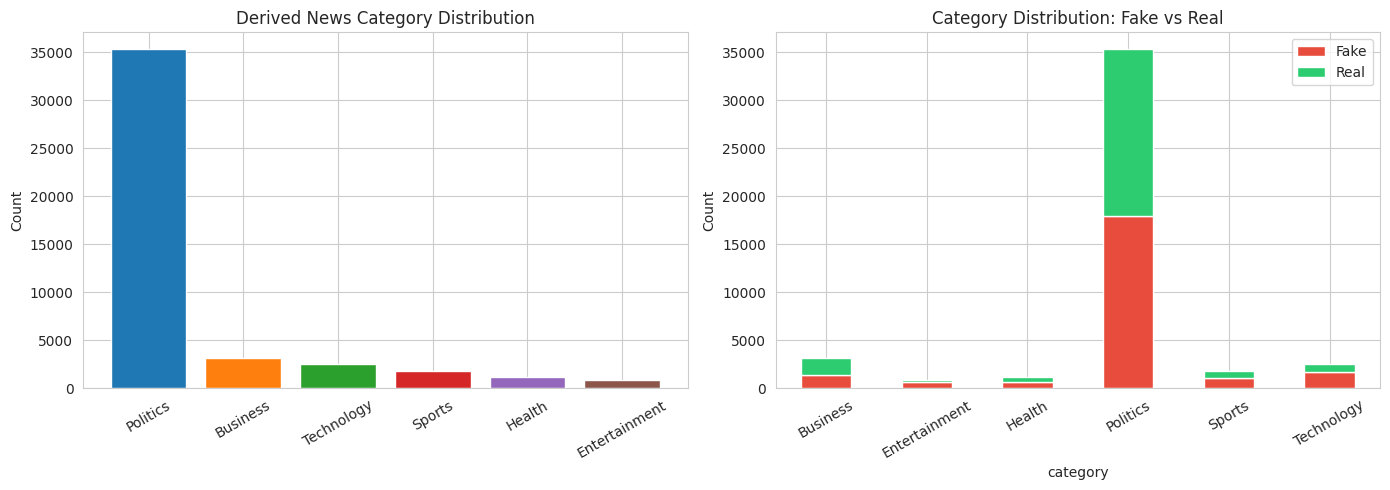

In [20]:
# -- Category Classification Functions ----------------------------------------

CATEGORY_KEYWORDS = {
    'Sports':        ['game', 'player', 'team', 'sport', 'match', 'tournament',
                      'championship', 'football', 'soccer', 'basketball', 'baseball',
                      'tennis', 'golf', 'olympic', 'athlete', 'coach', 'league',
                      'score', 'stadium', 'nfl', 'nba', 'fifa'],
    'Technology':    ['technology', 'tech', 'software', 'internet', 'digital',
                      'computer', 'cybersecurity', 'artificial intelligence', 'robot',
                      'smartphone', 'app', 'silicon', 'startup', 'innovation',
                      'algorithm', 'blockchain', 'cryptocurrency', 'cyber', 'hack'],
    'Health':        ['health', 'medical', 'doctor', 'hospital', 'disease', 'virus',
                      'vaccine', 'patient', 'treatment', 'drug', 'medicine', 'cancer',
                      'covid', 'pandemic', 'surgery', 'healthcare', 'fda', 'cdc',
                      'opioid', 'clinical', 'pharma'],
    'Entertainment': ['movie', 'film', 'music', 'celebrity', 'actor', 'actress',
                      'singer', 'entertainment', 'hollywood', 'award', 'oscar',
                      'grammy', 'concert', 'album', 'television', 'netflix', 'disney',
                      'comedy', 'drama', 'festival'],
    'Business':      ['business', 'economy', 'market', 'stock', 'trade', 'company',
                      'corporation', 'investment', 'bank', 'financial', 'profit',
                      'revenue', 'ceo', 'merger', 'gdp', 'inflation', 'recession',
                      'wall street', 'nasdaq', 'dow', 'federal reserve'],
    'Politics':      ['president', 'government', 'congress', 'senate', 'election',
                      'vote', 'democrat', 'republican', 'policy', 'white house',
                      'political', 'campaign', 'minister', 'parliament', 'trump',
                      'biden', 'obama', 'clinton', 'legislation', 'administration'],
}


def assign_news_category(text):
    text_lower = str(text).lower()
    scores = {cat: sum(1 for kw in kws if kw in text_lower)
              for cat, kws in CATEGORY_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Politics'


def prepare_category_labels(df, text_col='text'):
    df = df.copy()
    df['category'] = df[text_col].apply(assign_news_category)
    print("Category distribution:")
    print(df['category'].value_counts().to_string())
    return df


def train_category_classifier(X, y_cat, test_size=0.2):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_cat)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=42, stratify=y_enc)

    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
        'Naive Bayes':         MultinomialNB(),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    }

    results = {}
    for name, clf in classifiers.items():
        print(f"\nTraining {name} (category)...")
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, average='weighted')
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        results[name] = {
            'model': clf, 'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec,
            'y_pred': y_pred, 'y_test': y_test,
        }
        print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    return results, le, X_train, X_test, y_train, y_test


def plot_category_confusion_matrix(results, label_encoder):
    labels = label_encoder.classes_
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(res['y_test'], res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set_title(f'{name}\nCategory Acc: {res["accuracy"]:.4f}')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def print_category_report(results, label_encoder):
    labels = label_encoder.classes_
    for name, res in results.items():
        print(f"\n{'=' * 60}")
        print(f"Category Classification Report: {name}")
        print('=' * 60)
        print(classification_report(res['y_test'], res['y_pred'],
                                    target_names=labels, zero_division=0))


# Step 1: Assign keyword-based category labels
print("=" * 60)
print("MULTI-CLASS NEWS CATEGORY CLASSIFICATION")
print("=" * 60)

df_cat = prepare_category_labels(df, text_col='text')

# Visualise category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_cat['category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values,
            color=sns.color_palette('tab10', len(cat_counts)))
axes[0].set_title('Derived News Category Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

cross = df_cat.groupby(['category', 'label']).size().unstack(fill_value=0)
cross.columns = ['Fake', 'Real']
cross.plot(kind='bar', stacked=True, ax=axes[1],
           color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Category Distribution: Fake vs Real')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [21]:
# Step 2: Train multi-class category classifiers
cat_results, cat_encoder, cat_Xtr, cat_Xte, cat_ytr, cat_yte = train_category_classifier(
    tfidf_matrix, df_cat['category'].values
)

# Best category classifier (for use in the integrated pipeline)
best_cat_name = max(cat_results, key=lambda k: cat_results[k]['accuracy'])
best_cat_clf  = cat_results[best_cat_name]['model']
print(f"\nBest category classifier: {best_cat_name} "
      f"(Accuracy: {cat_results[best_cat_name]['accuracy']:.4f})")


Training Logistic Regression (category)...
  Accuracy: 0.8514 | F1: 0.8281 | Precision: 0.8378 | Recall: 0.8514

Training Naive Bayes (category)...
  Accuracy: 0.8092 | F1: 0.7611 | Precision: 0.7837 | Recall: 0.8092

Training Random Forest (category)...
  Accuracy: 0.8582 | F1: 0.8293 | Precision: 0.8758 | Recall: 0.8582

Best category classifier: Random Forest (Accuracy: 0.8582)


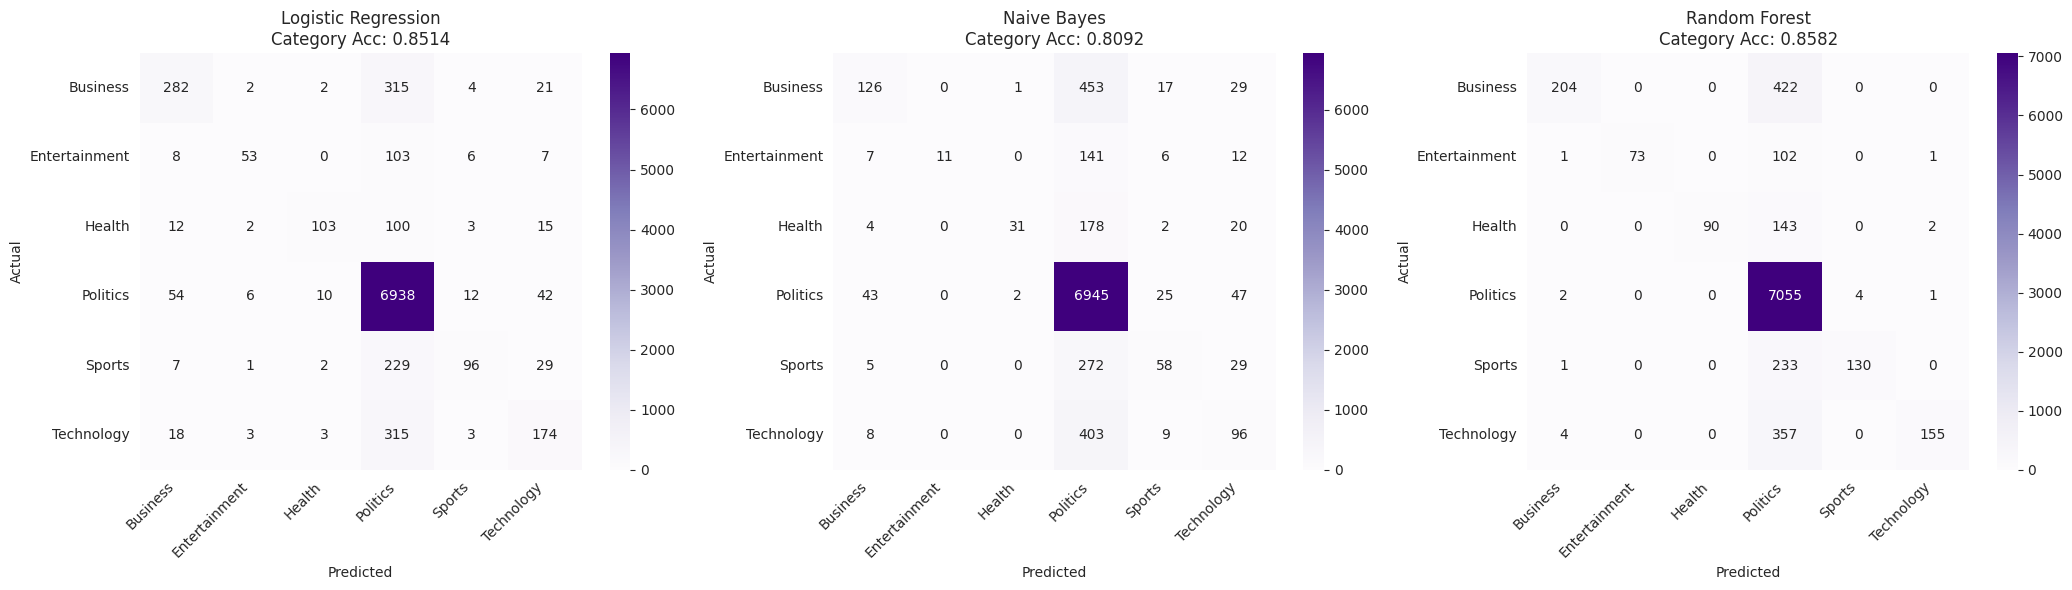


Category Classification Report: Logistic Regression
               precision    recall  f1-score   support

     Business       0.74      0.45      0.56       626
Entertainment       0.79      0.30      0.43       177
       Health       0.86      0.44      0.58       235
     Politics       0.87      0.98      0.92      7062
       Sports       0.77      0.26      0.39       364
   Technology       0.60      0.34      0.43       516

     accuracy                           0.85      8980
    macro avg       0.77      0.46      0.55      8980
 weighted avg       0.84      0.85      0.83      8980


Category Classification Report: Naive Bayes
               precision    recall  f1-score   support

     Business       0.65      0.20      0.31       626
Entertainment       1.00      0.06      0.12       177
       Health       0.91      0.13      0.23       235
     Politics       0.83      0.98      0.90      7062
       Sports       0.50      0.16      0.24       364
   Technology     

In [22]:
# Step 3: Evaluate — confusion matrices and detailed reports
plot_category_confusion_matrix(cat_results, cat_encoder)
print_category_report(cat_results, cat_encoder)

---
## 9. Fake News Detection - Deep Learning (LSTM)

We build an LSTM classifier using Word2Vec embeddings for fake news detection.

In [23]:
# Prepare Word2Vec document vectors
print("Building document vectors from Word2Vec...")

doc_vectors = np.array([get_document_vector_w2v(tokens, w2v_model) for tokens in df['tokens']])
print(f"Document vectors shape: {doc_vectors.shape}")

# Train-test split
X_dl_train, X_dl_test, y_dl_train, y_dl_test = train_test_split(
    doc_vectors, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'].values)

# Convert to tensors
X_dl_train_t = torch.FloatTensor(X_dl_train).unsqueeze(1)  # Add seq dim
X_dl_test_t = torch.FloatTensor(X_dl_test).unsqueeze(1)
y_dl_train_t = torch.LongTensor(y_dl_train)
y_dl_test_t = torch.LongTensor(y_dl_test)

DL_BATCH = BATCH_SIZE
train_ds = TensorDataset(X_dl_train_t, y_dl_train_t)
test_ds = TensorDataset(X_dl_test_t, y_dl_test_t)
train_dl = DataLoader(train_ds, batch_size=DL_BATCH, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=DL_BATCH)
print(f"BiLSTM batch size: {DL_BATCH}")

Building document vectors from Word2Vec...
Document vectors shape: (44898, 100)
BiLSTM batch size: 256


Training BiLSTM Classifier...
  Epoch 5/20, Loss: 0.0626
  Epoch 10/20, Loss: 0.0498
  Epoch 15/20, Loss: 0.0391
  Epoch 20/20, Loss: 0.0342


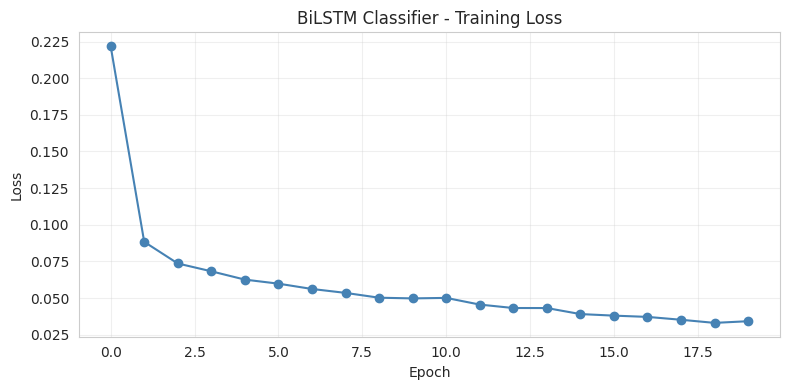

In [24]:
# BiLSTM Classifier Definition
class LSTMClassifier(nn.Module):
    """BiLSTM classifier for fake news detection."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

# Train LSTM classifier
lstm_clf = LSTMClassifier(input_dim=100).to(DEVICE)
optimizer = torch.optim.Adam(lstm_clf.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

lstm_losses = []
print("Training BiLSTM Classifier...")
for epoch in range(20):
    lstm_clf.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = lstm_clf(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dl)
    lstm_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20, Loss: {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(lstm_losses, marker='o', color='steelblue')
plt.title('BiLSTM Classifier - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


BiLSTM CLASSIFIER RESULTS
Accuracy: 0.9834

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      4696
        Real       0.98      0.98      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



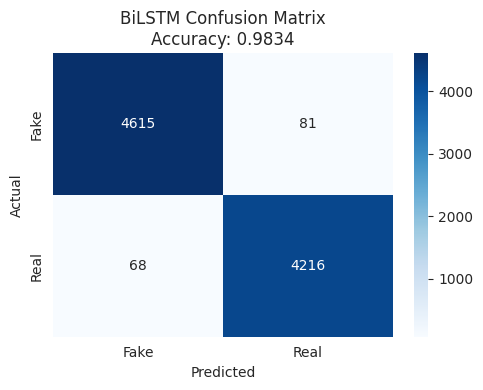

In [25]:
# Evaluate LSTM classifier
lstm_clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        out = lstm_clf(xb)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

print("\n" + "=" * 60)
print("BiLSTM CLASSIFIER RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print("\n" + classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], ax=ax)
ax.set_title(f'BiLSTM Confusion Matrix\nAccuracy: {accuracy_score(all_labels, all_preds):.4f}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 10. Integrated Analysis Pipeline

Enter any news article text and get a complete NLP analysis:
- Predicted category (Fake/Real)
- Keywords & Named Entities
- POS Tags
- Parsing results
- Prediction probabilities

In [26]:
# ---------- Integrated Analysis Function ----------
def analyze_article(text, tfidf_vec, best_clf, w2v_model, nlp_model,
                    cat_clf=None, cat_encoder=None):
    """Complete NLP analysis pipeline for a news article."""
    print("=" * 70)
    print("INTEGRATED NEWS ARTICLE ANALYSIS")
    print("=" * 70)
    print(f"\nInput text (first 200 chars): {text[:200]}...")

    # 1. Preprocessing
    tokens = preprocess_text(text)
    processed = ' '.join(tokens)

    # 2. Fake News Detection (TF-IDF + best traditional classifier)
    tfidf_feat = tfidf_vec.transform([processed])
    pred  = best_clf.predict(tfidf_feat)[0]
    proba = best_clf.predict_proba(tfidf_feat)[0]
    label = 'REAL' if pred == 1 else 'FAKE'
    print(f"\n--- FAKE NEWS DETECTION ---")
    print(f"  Prediction: {label}")
    print(f"  Confidence: Fake={proba[0]:.4f}, Real={proba[1]:.4f}")

    # 3. News Category Prediction
    predicted_category = 'N/A'
    if cat_clf is not None and cat_encoder is not None:
        cat_pred_enc = cat_clf.predict(tfidf_feat)[0]
        predicted_category = cat_encoder.inverse_transform([cat_pred_enc])[0]
        if hasattr(cat_clf, 'predict_proba'):
            cat_proba = cat_clf.predict_proba(tfidf_feat)[0]
            cat_conf  = dict(zip(cat_encoder.classes_, [f'{p:.3f}' for p in cat_proba]))
            print(f"\n--- NEWS CATEGORY ---")
            print(f"  Predicted Category: {predicted_category}")
            print(f"  Category Scores   : {cat_conf}")
        else:
            print(f"\n--- NEWS CATEGORY ---")
            print(f"  Predicted Category: {predicted_category}")
    else:
        predicted_category = assign_news_category(text)
        print(f"\n--- NEWS CATEGORY (keyword-based) ---")
        print(f"  Predicted Category: {predicted_category}")

    # 4. Keywords
    print(f"\n--- KEYWORDS ---")
    print(f"  Top tokens: {tokens[:15]}")

    # 5. POS Tagging
    tagged     = pos_tag_text(text[:1000])
    categories = extract_pos_categories(tagged)
    print(f"\n--- POS TAGGING ---")
    print(f"  Nouns: {categories['nouns'][:10]}")
    print(f"  Verbs: {categories['verbs'][:10]}")

    # 6. Named Entities
    entities = extract_named_entities(text[:1000])
    print(f"\n--- NAMED ENTITIES (NLTK) ---")
    print(f"  {entities[:10]}")

    # 7. SpaCy NER
    doc        = nlp_model(text[:2000])
    sp_entities = [(ent.text, ent.label_) for ent in doc.ents]
    print(f"\n--- SPACY ENTITIES ---")
    print(f"  {sp_entities[:10]}")

    # 8. Parsing
    triples, _ = dependency_parse(text[:1000], nlp_model)
    print(f"\n--- PARSING (SVO Triples) ---")
    for t in triples[:5]:
        print(f"  {t['subject']} -- {t['verb']} --> {t['object']}")

    print("\n" + "=" * 70)
    return {
        'label':              label,
        'confidence':         proba,
        'predicted_category': predicted_category,
        'keywords':           tokens[:15],
        'entities':           sp_entities[:10],
        'triples':            triples[:5],
    }

In [27]:
# Select best fake-news classifier
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_clf  = results[best_name]['model']
print(f"Using best fake-news classifier: {best_name} "
      f"(Accuracy: {results[best_name]['accuracy']:.4f})")

# Test with sample articles
sample_real = df[df['label'] == 1]['text'].iloc[0]
sample_fake = df[df['label'] == 0]['text'].iloc[0]

print("\n" + "#" * 70)
print("TEST 1: Real News Article")
print("#" * 70)
analyze_article(sample_real, tfidf_vectorizer, best_clf, w2v_model, nlp,
                cat_clf=best_cat_clf, cat_encoder=cat_encoder)

print("\n" + "#" * 70)
print("TEST 2: Fake News Article")
print("#" * 70)
analyze_article(sample_fake, tfidf_vectorizer, best_clf, w2v_model, nlp,
                cat_clf=best_cat_clf, cat_encoder=cat_encoder)

Using best fake-news classifier: Random Forest (Accuracy: 0.9969)

######################################################################
TEST 1: Real News Article
######################################################################
INTEGRATED NEWS ARTICLE ANALYSIS

Input text (first 200 chars): SAN FRANCISCO (Reuters) - California Attorney General Xavier Becerra said on Friday he was “prepared to take whatever action it takes” to defend the Obamacare mandate that health insurers provide birt...

--- FAKE NEWS DETECTION ---
  Prediction: REAL
  Confidence: Fake=0.0300, Real=0.9700

--- NEWS CATEGORY ---
  Predicted Category: Politics
  Category Scores   : {'Business': '0.000', 'Entertainment': '0.010', 'Health': '0.040', 'Politics': '0.930', 'Sports': '0.000', 'Technology': '0.020'}

--- KEYWORDS ---
  Top tokens: ['san', 'francisco', 'reuters', 'california', 'attorney', 'general', 'xavier', 'becerra', 'said', 'friday', 'prepared', 'take', 'whatever', 'action', 'take']

--- POS TAGGI

{'label': 'FAKE',
 'confidence': array([1., 0.]),
 'predicted_category': 'Politics',
 'keywords': ['donald',
  'trump',
  'white',
  'house',
  'chaos',
  'trying',
  'cover',
  'russia',
  'problem',
  'mounting',
  'hour',
  'refuse',
  'acknowledge',
  'problem',
  'surrounding'],
 'entities': [('Donald Trump', 'PERSON'),
  ('White House', 'ORG'),
  ('Russia', 'GPE'),
  ('the hour', 'TIME'),
  ('Congressional', 'NORP'),
  ('Chuck Grassley', 'PERSON'),
  ('the Senate Judiciary Committee', 'ORG'),
  ('Donald Trump', 'PERSON'),
  ('Jr.', 'PERSON'),
  ('2016', 'DATE')],
 'triples': [{'subject': 'House', 'verb': 'is', 'object': ''},
  {'subject': 'they', 'verb': 'trying', 'object': ''},
  {'subject': 'problems', 'verb': 'mounting', 'object': ''},
  {'subject': 'they', 'verb': 'refuse', 'object': ''},
  {'subject': 'it', 'verb': 's', 'object': 'news'}]}

In [28]:
# Test with custom text
custom_text = """
The government announced a new policy to regulate artificial intelligence 
technology in the healthcare sector. The president signed the executive order 
during a press conference at the White House. Officials said the new regulations 
would protect patient privacy while encouraging innovation in medical AI applications.
"""

print("#" * 70)
print("TEST 3: Custom News Article")
print("#" * 70)
analyze_article(custom_text, tfidf_vectorizer, best_clf, w2v_model, nlp,
                cat_clf=best_cat_clf, cat_encoder=cat_encoder)

######################################################################
TEST 3: Custom News Article
######################################################################
INTEGRATED NEWS ARTICLE ANALYSIS

Input text (first 200 chars): 
The government announced a new policy to regulate artificial intelligence 
technology in the healthcare sector. The president signed the executive order 
during a press conference at the White House....

--- FAKE NEWS DETECTION ---
  Prediction: FAKE
  Confidence: Fake=0.6100, Real=0.3900

--- NEWS CATEGORY ---
  Predicted Category: Politics
  Category Scores   : {'Business': '0.020', 'Entertainment': '0.000', 'Health': '0.210', 'Politics': '0.630', 'Sports': '0.000', 'Technology': '0.140'}

--- KEYWORDS ---
  Top tokens: ['government', 'announced', 'new', 'policy', 'regulate', 'artificial', 'intelligence', 'technology', 'healthcare', 'sector', 'president', 'signed', 'executive', 'order', 'press']

--- POS TAGGING ---
  Nouns: ['government', 'policy', 'in

{'label': 'FAKE',
 'confidence': array([0.60996689, 0.39003311]),
 'predicted_category': 'Politics',
 'keywords': ['government',
  'announced',
  'new',
  'policy',
  'regulate',
  'artificial',
  'intelligence',
  'technology',
  'healthcare',
  'sector',
  'president',
  'signed',
  'executive',
  'order',
  'press'],
 'entities': [('the White House', 'FAC')],
 'triples': [{'subject': 'government',
   'verb': 'announced',
   'object': 'policy'},
  {'subject': 'president', 'verb': 'signed', 'object': 'order'},
  {'subject': 'Officials', 'verb': 'said', 'object': ''},
  {'subject': 'regulations', 'verb': 'protect', 'object': 'privacy'}]}

---
## 11. Save Models

In [29]:
os.makedirs('models', exist_ok=True)

# Save Word2Vec
w2v_model.save('models/word2vec.model')

# Save TF-IDF vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Save best fake-news classifier
with open('models/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_clf, f)

# Save category classifier + encoder
with open('models/category_classifier.pkl', 'wb') as f:
    pickle.dump({'model': best_cat_clf, 'encoder': cat_encoder}, f)

# Save HMM classifier
with open('models/hmm_classifier.pkl', 'wb') as f:
    pickle.dump(hmm_clf, f)

# Save LSTM models
torch.save(lm_model.state_dict(), 'models/lstm_lm.pth')
torch.save(lstm_clf.state_dict(), 'models/lstm_classifier.pth')

print("All models saved to models/ directory.")

Word2Vec model saved to models/word2vec.model
All models saved to models/ directory.


---
## 12. Performance Summary

### Results Table

In [30]:
# Final Performance Summary
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

# ---------- Fake News Detection Summary ----------
summary_data = []
for name, res in results.items():
    summary_data.append({
        'Model': name,
        'Task': 'Fake News Detection',
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall': f"{res['recall']:.4f}",
    })

# Add BiLSTM results
lstm_acc = accuracy_score(all_labels, all_preds)
summary_data.append({
    'Model': 'BiLSTM (W2V)',
    'Task': 'Fake News Detection',
    'Accuracy': f"{lstm_acc:.4f}",
    'F1-Score': f"{f1_score(all_labels, all_preds, average='weighted'):.4f}",
    'Precision': f"{precision_score(all_labels, all_preds, average='weighted'):.4f}",
    'Recall': f"{recall_score(all_labels, all_preds, average='weighted'):.4f}",
})

# Add HMM results
summary_data.append({
    'Model': 'HMM (entropy+state)',
    'Task': 'Fake News Detection',
    'Accuracy': f"{hmm_acc:.4f}",
    'F1-Score': f"{hmm_f1:.4f}",
    'Precision': 'N/A',
    'Recall': 'N/A',
})

# ---------- Category Classification Summary ----------
for name, res in cat_results.items():
    summary_data.append({
        'Model': name,
        'Task': 'Category Classification',
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall': f"{res['recall']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))


FINAL PERFORMANCE SUMMARY
              Model                    Task Accuracy F1-Score Precision Recall
Logistic Regression     Fake News Detection   0.9888   0.9888    0.9888 0.9888
        Naive Bayes     Fake News Detection   0.9492   0.9492    0.9493 0.9492
      Random Forest     Fake News Detection   0.9969   0.9969    0.9969 0.9969
       BiLSTM (W2V)     Fake News Detection   0.9834   0.9834    0.9834 0.9834
HMM (entropy+state)     Fake News Detection   0.7008   0.6843       N/A    N/A
Logistic Regression Category Classification   0.8514   0.8281    0.8378 0.8514
        Naive Bayes Category Classification   0.8092   0.7611    0.7837 0.8092
      Random Forest Category Classification   0.8582   0.8293    0.8758 0.8582


---
## Conclusion and evidence of running assignment on BITS virtual lab

As part of this assignment we have successfully implemented and demonstrated an end-to-end NLP pipeline for news article classification and fake news detection.  
Key findings:
1. **TF-IDF + Logistic Regression** provides a strong baseline with high accuracy
2. **Word2Vec embeddings** capture semantic relationships between news terms
3. **LSTM language model** learns contextual patterns in news text
4. **POS tagging and NER** extract meaningful entities and keywords
5. **HMM** models POS tag transition patterns that differ between fake and real news
6. **Dependency parsing** reveals structural relationships in news sentences

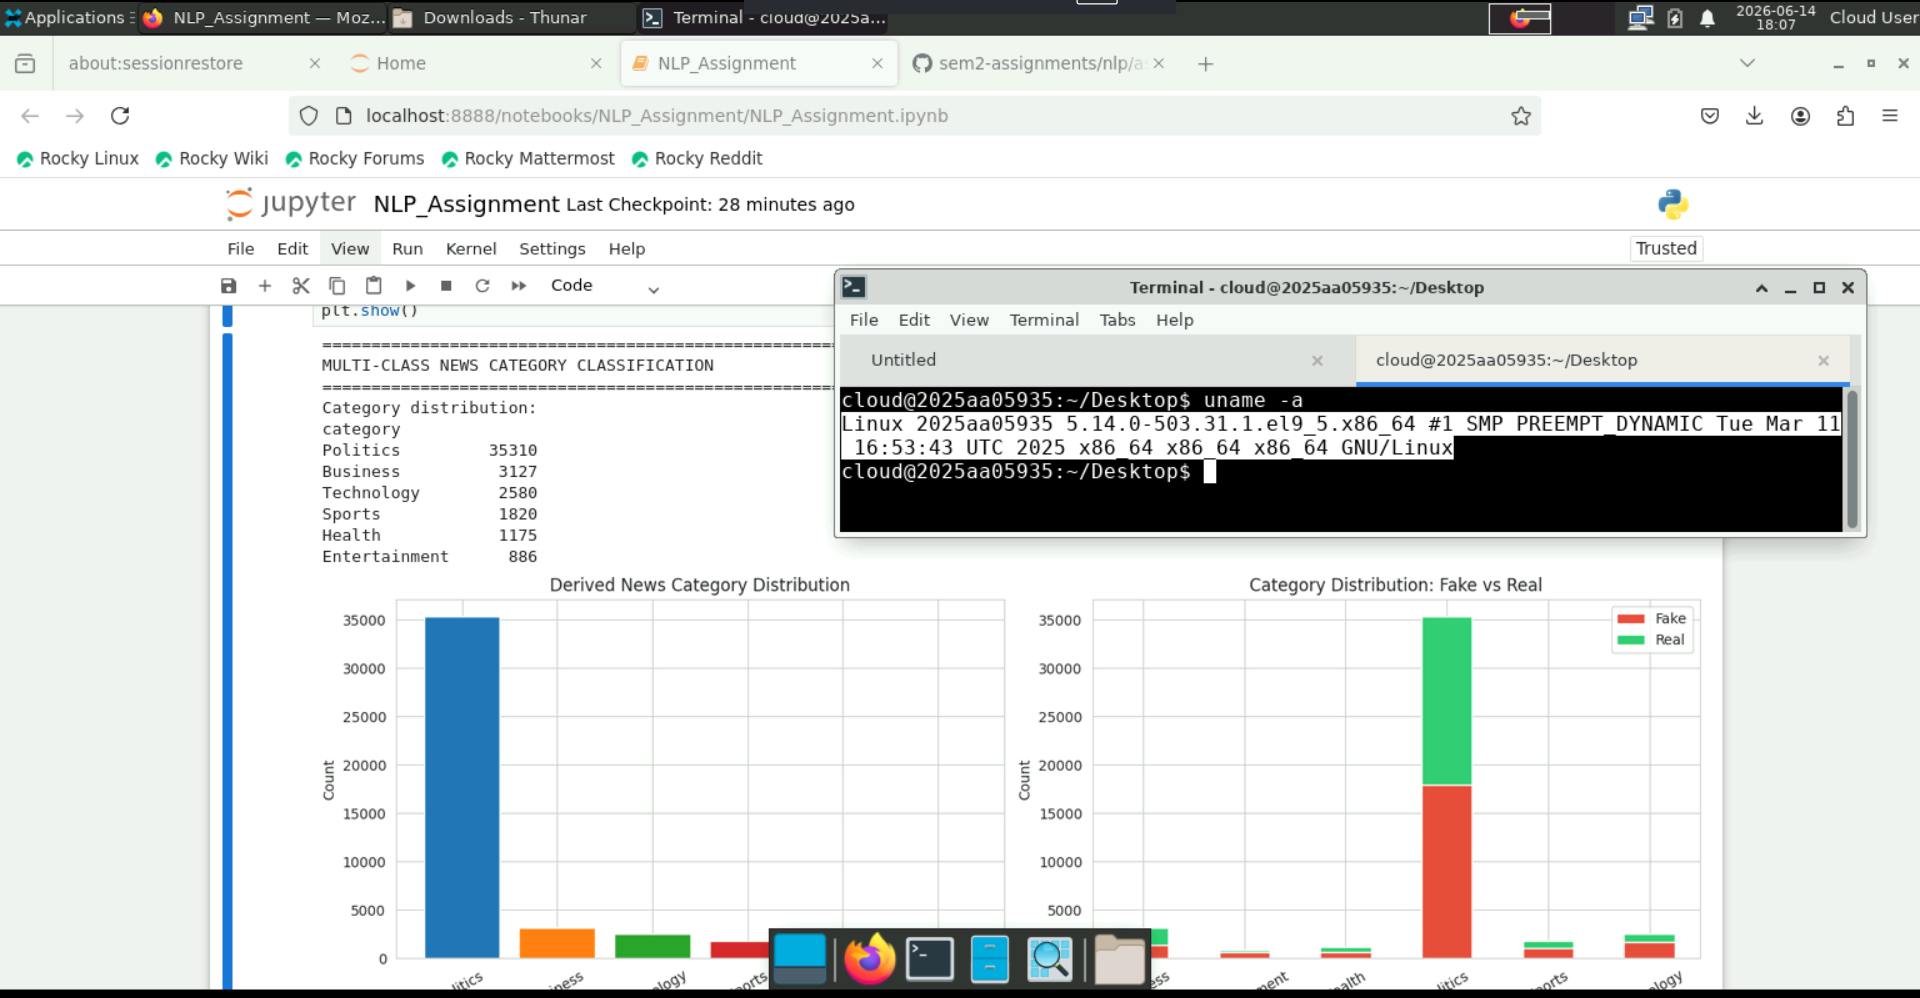

---